In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

np.random.seed(42)

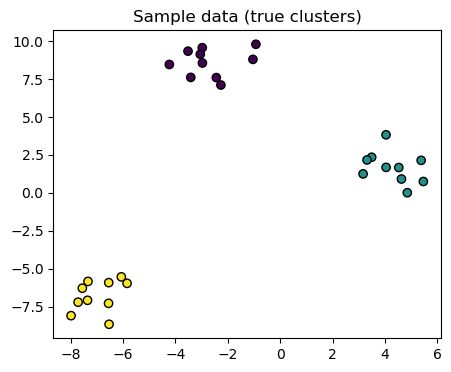

In [2]:
X, y_true = make_blobs(n_samples=30, centers=3, cluster_std=1.0, random_state=42)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap="viridis", edgecolor="k")
plt.title("Sample data (true clusters)")
plt.show()

In [3]:
def pairwise_distances(X):
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

D = pairwise_distances(X)
print(D.shape)

(30, 30)


In [4]:
def agglomerative(X, method="average"):
    n = len(X)
    D = pairwise_distances(X)
    clusters = {i: [i] for i in range(n)}   # cluster id -> member indices
    Z = []
    next_id = n

    def cluster_distance(a, b):
        if method == "single":
            return D[np.ix_(a, b)].min()
        if method == "complete":
            return D[np.ix_(a, b)].max()
        if method == "average":
            return D[np.ix_(a, b)].mean()
        if method == "ward":
            ca, cb = X[a].mean(axis=0), X[b].mean(axis=0)
            na, nb = len(a), len(b)
            # same scaling SciPy uses for Ward
            return np.sqrt(2 * na * nb / (na + nb)) * np.linalg.norm(ca - cb)
        raise ValueError("Unknown linkage method")

    while len(clusters) > 1:
        ids = list(clusters)
        best = (np.inf, None, None)
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                d = cluster_distance(clusters[ids[i]], clusters[ids[j]])
                if d < best[0]:
                    best = (d, ids[i], ids[j])

        d, a, b = best
        merged = clusters.pop(a) + clusters.pop(b)
        clusters[next_id] = merged
        Z.append([a, b, d, len(merged)])
        next_id += 1

    return np.array(Z, dtype=float)

Z_mine = agglomerative(X, method="average")
print(Z_mine[:5])

[[ 2.         15.          0.25175338  2.        ]
 [20.         21.          0.38065287  2.        ]
 [ 0.         14.          0.4380892   2.        ]
 [16.         22.          0.47783018  2.        ]
 [10.         12.          0.48508169  2.        ]]


In [5]:
for m in ["single", "complete", "average", "ward"]:
    mine = agglomerative(X, method=m)
    ref = linkage(X, method=m)
    print(f"{m:9s} merge distances match SciPy:", np.allclose(mine[:, 2], ref[:, 2]))

single    merge distances match SciPy: True
complete  merge distances match SciPy: True
average   merge distances match SciPy: True
ward      merge distances match SciPy: True


In [6]:
def cut_tree(Z, n, k):
    """Replay the first (n - k) merges and return cluster labels."""
    members = {i: [i] for i in range(n)}
    for step in range(n - k):
        a, b = int(Z[step, 0]), int(Z[step, 1])
        members[n + step] = members.pop(a) + members.pop(b)
    labels = np.zeros(n, dtype=int)
    for lab, pts in enumerate(members.values()):
        labels[pts] = lab
    return labels

labels_agg = cut_tree(Z_mine, len(X), k=3)
print("ARI vs. truth (average linkage):", adjusted_rand_score(y_true, labels_agg))

ARI vs. truth (average linkage): 1.0


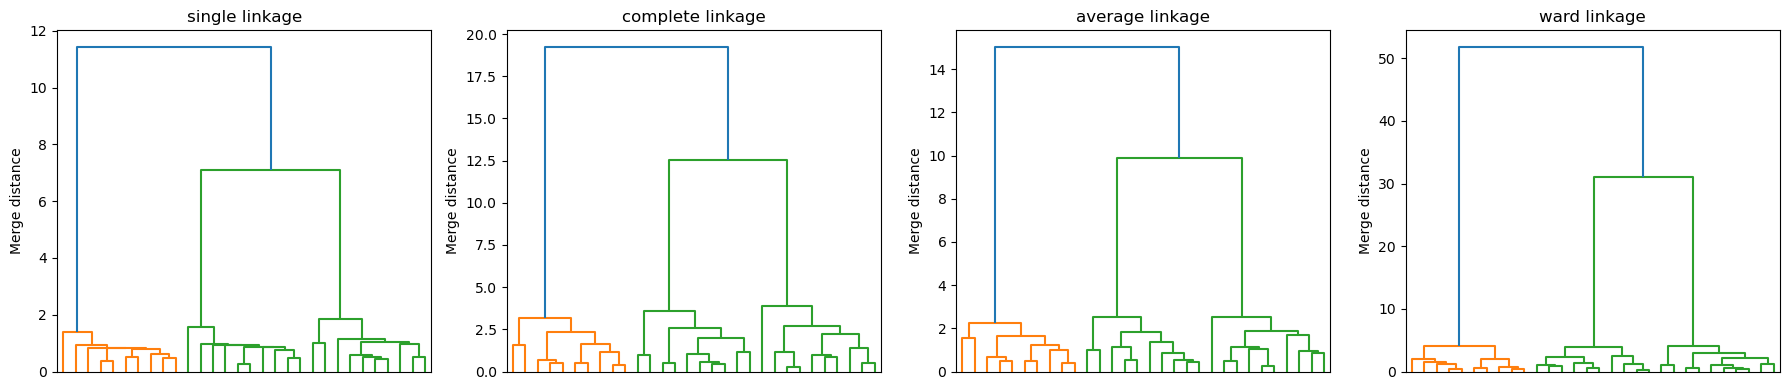

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, m in zip(axes, ["single", "complete", "average", "ward"]):
    dendrogram(agglomerative(X, m), ax=ax, no_labels=True)
    ax.set_title(f"{m} linkage")
    ax.set_ylabel("Merge distance")
plt.tight_layout()
plt.show()

ARI mine vs sklearn: 1.0


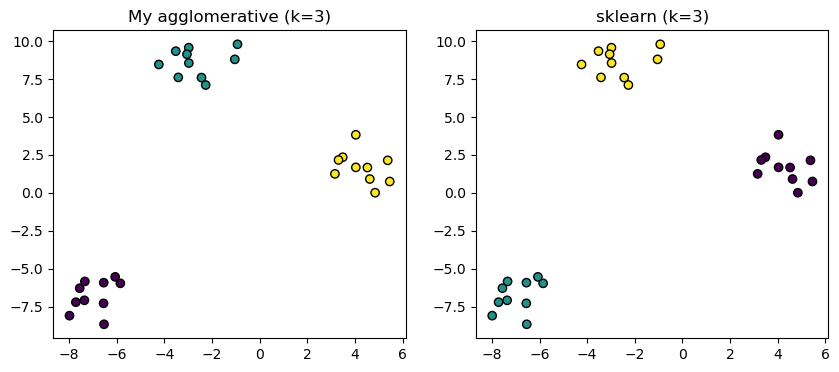

In [8]:
sk = AgglomerativeClustering(n_clusters=3, linkage="average").fit(X)
print("ARI mine vs sklearn:", adjusted_rand_score(labels_agg, sk.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_agg, cmap="viridis", edgecolor="k")
axes[0].set_title("My agglomerative (k=3)")
axes[1].scatter(X[:, 0], X[:, 1], c=sk.labels_, cmap="viridis", edgecolor="k")
axes[1].set_title("sklearn (k=3)")
plt.show()

In [9]:
def diana(X):
    n = len(X)
    D = pairwise_distances(X)
    clusters = [list(range(n))]
    snapshots = [[c[:] for c in clusters]]   # snapshots[k-1] = partition with k clusters
    split_diameters = []

    while len(clusters) < n:
        # 1. Choose the cluster with the largest diameter
        diam = [D[np.ix_(c, c)].max() if len(c) > 1 else 0 for c in clusters]
        idx = int(np.argmax(diam))
        split_diameters.append(diam[idx])
        C = clusters.pop(idx)

        # 2. Seed the splinter group
        rest, splinter = C[:], []
        avg = D[np.ix_(rest, rest)].sum(axis=1) / (len(rest) - 1)
        splinter.append(rest.pop(int(np.argmax(avg))))

        # 3. Move points that are closer to the splinter group
        while len(rest) > 1:
            d_rest = D[np.ix_(rest, rest)].sum(axis=1) / (len(rest) - 1)
            d_spl = D[np.ix_(rest, splinter)].mean(axis=1)
            gain = d_rest - d_spl
            k = int(np.argmax(gain))
            if gain[k] <= 0:
                break
            splinter.append(rest.pop(k))

        clusters += [rest, splinter]
        snapshots.append([c[:] for c in clusters])

    return snapshots, split_diameters

snapshots, split_diams = diana(X)
print("First split sizes:", [len(c) for c in snapshots[1]])

First split sizes: [20, 10]


In [10]:
def labels_from_snapshot(snapshot, n):
    labels = np.zeros(n, dtype=int)
    for lab, pts in enumerate(snapshot):
        labels[pts] = lab
    return labels

labels_div = labels_from_snapshot(snapshots[2], len(X))   # 3 clusters
print("ARI vs. truth (DIANA, k=3):", adjusted_rand_score(y_true, labels_div))

ARI vs. truth (DIANA, k=3): 1.0
